In [3]:
import yfinance as yf
import matplotlib.pyplot as plt

In [1]:
def calculate_rsi(data, periods=14):
    """
    Calculate RSI for the given price data
    
    Parameters:
    data (pd.Series): Price series
    periods (int): RSI period, default is 14
    
    Returns:
    pd.Series: RSI values
    """
    # Calculate price changes
    delta = data.diff()
    
    # Separate gains and losses
    gain = (delta.where(delta > 0, 0))
    loss = (-delta.where(delta < 0, 0))
    
    # Calculate average gain and loss
    avg_gain = gain.rolling(window=periods).mean()
    avg_loss = loss.rolling(window=periods).mean()
    
    # Calculate RS and RSI
    rs = avg_gain / avg_loss
    rsi = 100 - (100 / (1 + rs))
    
    return rsi

def generate_signals(df, rsi_period=14, overbought=70, oversold=30):
    """
    Generate buy/sell signals based on RSI
    
    Parameters:
    df (pd.DataFrame): DataFrame with price data
    rsi_period (int): RSI calculation period
    overbought (float): RSI overbought threshold
    oversold (float): RSI oversold threshold
    
    Returns:
    pd.DataFrame: DataFrame with signals
    """
    # Calculate RSI
    df['RSI'] = calculate_rsi(df['Close'], rsi_period)
    
    # Initialize signal columns
    df['Buy_Signal'] = 0
    df['Sell_Signal'] = 0
    
    # Generate buy signals (RSI crosses below oversold)
    df.loc[df['RSI'] < oversold, 'Buy_Signal'] = 1
    
    # Generate sell signals (RSI crosses above overbought)
    df.loc[df['RSI'] > overbought, 'Sell_Signal'] = 1
    
    return df

def plot_signals(df, title='RSI Buy/Sell Signals'):
    """
    Plot stock price, RSI, and buy/sell signals
    
    Parameters:
    df (pd.DataFrame): DataFrame with price and signal data
    title (str): Plot title
    """
    # Create figure with subplots
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10), height_ratios=[2, 1])
    
    # Plot price
    ax1.plot(df.index, df['Close'], label='Close Price', alpha=0.8)
    
    # Plot buy signals
    buy_points = df[df['Buy_Signal'] == 1]
    ax1.scatter(buy_points.index, buy_points['Close'], 
                color='green', marker='^', s=100, label='Buy Signal')
    
    # Plot sell signals
    sell_points = df[df['Sell_Signal'] == 1]
    ax1.scatter(sell_points.index, sell_points['Close'], 
                color='red', marker='v', s=100, label='Sell Signal')
    
    # Configure price plot
    ax1.set_title(title)
    ax1.set_ylabel('Price')
    ax1.legend()
    ax1.grid(True)
    
    # Plot RSI
    ax2.plot(df.index, df['RSI'], label='RSI', color='purple')
    ax2.axhline(y=70, color='r', linestyle='--', alpha=0.5)
    ax2.axhline(y=30, color='g', linestyle='--', alpha=0.5)
    
    # Configure RSI plot
    ax2.set_ylabel('RSI')
    ax2.set_xlabel('Date')
    ax2.legend()
    ax2.grid(True)
    
    plt.tight_layout()
    plt.show()


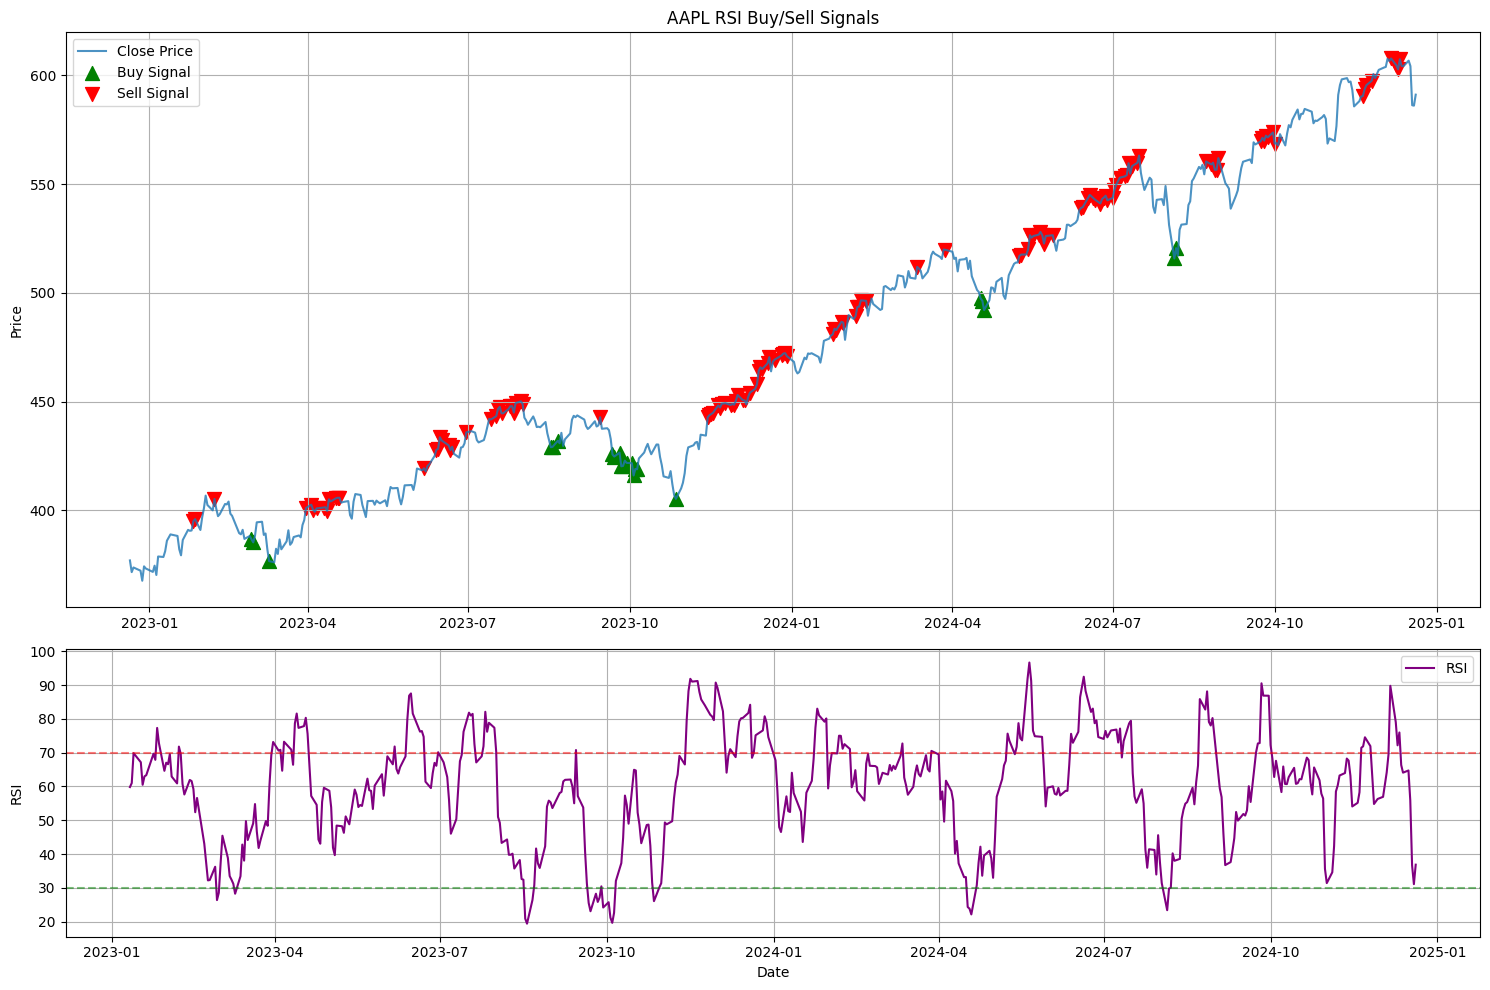


Signal Summary:
Number of Buy Signals: 22
Number of Sell Signals: 128


In [5]:
# Get AAPL data for the last year
ticker_value = 'SPY'
ticker = yf.Ticker(ticker_value)
df = ticker.history(period="2y")

# Generate signals
signals_df = generate_signals(df)

# Plot results
plot_signals(signals_df, ticker_value + ' RSI Buy/Sell Signals')

# Print summary of signals
print("\nSignal Summary:")
print(f"Number of Buy Signals: {len(signals_df[signals_df['Buy_Signal'] == 1])}")
print(f"Number of Sell Signals: {len(signals_df[signals_df['Sell_Signal'] == 1])}")